# 📊 Relatório 4 – Permutation Importance Geral, por Classe e SHAP

Este notebook implementa as três análises de interpretabilidade do modelo Random Forest
treinado para classificar a **severidade** das lesões de futebol europeu em:

| Classe | Critério |
|--------|----------|
| `leve` | ≤ 15 dias de afastamento |
| `moderada` | 16 – 60 dias |
| `grave` | > 60 dias |

**Conteúdo:**
1. Carregamento e preparação dos dados
2. Treinamento do modelo base
3. Permutation Importance Geral
4. Permutation Importance por Classe
5. Análise SHAP


## 1. Importações e Carregamento de Dados

In [1]:
import sys, os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    classification_report, f1_score,
    ConfusionMatrixDisplay, confusion_matrix
)

warnings.filterwarnings('ignore')
shap.initjs()
print('Bibliotecas carregadas com sucesso.')

D:\Desenvolver\pUC\pmv-si-2026-1-pe7-t1-g3-analytics_lesao_futebol-main\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Bibliotecas carregadas com sucesso.


In [2]:
sys.path.append(os.path.abspath(os.path.join('..', '..')))
from src.data_loader import load_injuries_data

df = load_injuries_data()

# Renomear colunas para português
df = df.rename(columns={
    'Season': 'temporada',
    'Injury': 'tipo_lesao',
    'Days': 'duracao_dias',
    'Games missed': 'jogos_perdidos',
    'injury_from_parsed': 'data_inicio_lesao',
    'injury_until_parsed': 'data_fim_lesao',
    'player_name': 'jogador',
    'player_age': 'idade',
    'player_position': 'posicao',
    'club': 'clube',
    'league': 'liga',
})

# Converter duracao_dias para numérico
df['duracao_dias'] = (
    df['duracao_dias'].astype(str)
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

print(f'Dataset carregado: {df.shape[0]} registros, {df.shape[1]} colunas')
df.head(3)

Dataset carregado: 15603 registros, 11 colunas


,temporada,tipo_lesao,duracao_dias,jogos_perdidos,data_inicio_lesao,data_fim_lesao,jogador,idade,posicao,clube,liga
0,20/21,Syndesmosis ligament tear,43,9,1/28/2021,3/11/2021,Alexander Nübel,24,Goalkeeper,Bayern Munich,Bundesliga
1,20/21,Knee injury,37,6,3/7/2021,4/12/2021,Ron-Thorben Hoffmann,22,Goalkeeper,Bayern Munich,Bundesliga
2,20/21,Corona virus,21,4,2/17/2021,3/9/2021,Benjamin Pavard,25,Centre-Back,Bayern Munich,Bundesliga


## 2. Preparação das Features e Treinamento do Modelo

### Variável-alvo: `severidade`

Criamos a variável `severidade` a partir de `duracao_dias`, classificando cada lesão em
**leve**, **moderada** ou **grave**.

### Features utilizadas

| Feature | Tipo | Justificativa |
|---------|------|---------------|
| `idade` | Numérica | Perfil físico do atleta |
| `posicao` | Categórica (encoded) | Demanda biomecânica por posição |
| `liga` | Categórica (encoded) | Contexto esportivo/calendário |

> **Nota:** `duracao_dias` e `jogos_perdidos` são excluídas para evitar **data leakage**,
> pois `severidade` é derivada diretamente de `duracao_dias`.

In [3]:
# ── Criar variável-alvo ──────────────────────────────────────────────────
max_dias = df['duracao_dias'].max()
df['severidade'] = pd.cut(
    df['duracao_dias'],
    bins=[0, 15, 60, max_dias],
    labels=['leve', 'moderada', 'grave'],
    include_lowest=True
)

print('Distribuição da variável-alvo:')
print(df['severidade'].value_counts())
print(f'\nProporção (%):')
print((df['severidade'].value_counts(normalize=True) * 100).round(1))

Distribuição da variável-alvo:
severidade
leve        6986
moderada    6299
grave       2318
Name: count, dtype: int64

Proporção (%):
severidade
leve        44.8
moderada    40.4
grave       14.9
Name: proportion, dtype: float64


In [4]:
# ── Preparar features ───────────────────────────────────────────────────
features_cat = ['posicao', 'liga']
features_num = ['idade']
target = 'severidade'

df_model = df[features_num + features_cat + [target]].dropna().copy()

# One-Hot Encoding
df_encoded = pd.get_dummies(df_model, columns=features_cat, drop_first=False)

X = df_encoded.drop(columns=[target])
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras')
print(f'Features: {X.shape[1]} colunas')

Treino: 12482 amostras | Teste: 3121 amostras
Features: 20 colunas


In [5]:
# ── Treinar Random Forest ────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print('=== Relatório de Classificação ===')
print(classification_report(y_test, y_pred, zero_division=0))

=== Relatório de Classificação ===
              precision    recall  f1-score   support

       grave       0.21      0.40      0.27       464
        leve       0.53      0.52      0.52      1397
    moderada       0.45      0.31      0.37      1260

    accuracy                           0.42      3121
   macro avg       0.40      0.41      0.39      3121
weighted avg       0.45      0.42      0.42      3121



## 3. Permutation Importance Geral

**O que é?** A Permutation Importance embaralha aleatoriamente os valores de uma feature
e mede o quanto a métrica do modelo (F1-ponderado) cai. Quanto maior a queda, mais
**importante** é aquela feature para o modelo.

**Por que usar?** Diferente da importância nativa da árvore (impurity-based), a
Permutation Importance é mais confiável para features categóricas com muitas categorias
(como `posicao` e `liga` após o encoding).

**Parâmetros:** `n_repeats=30` — cada feature é embaralhada 30 vezes para estabilizar
a estimativa. O gráfico mostra a **média ± desvio padrão** das 30 repetições.

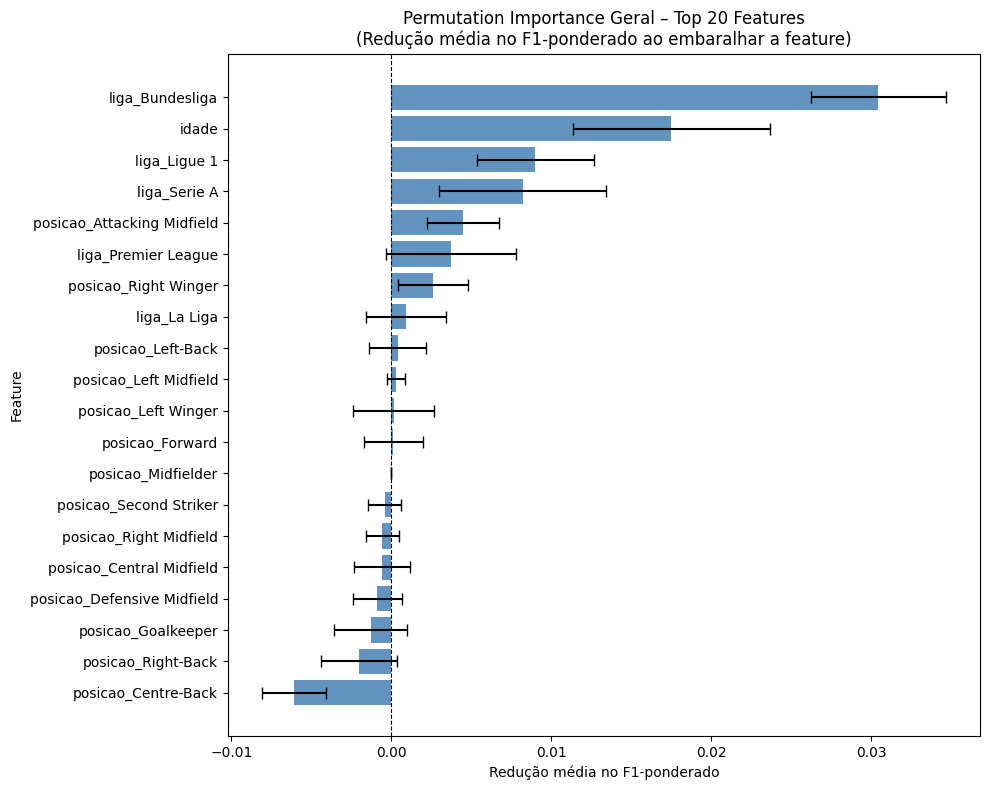


Top 10 features mais importantes:
                   feature  importance_mean  importance_std
           liga_Bundesliga         0.030431        0.004216
                     idade         0.017480        0.006159
              liga_Ligue 1         0.008997        0.003679
              liga_Serie A         0.008194        0.005211
posicao_Attacking Midfield         0.004461        0.002261
       liga_Premier League         0.003717        0.004081
      posicao_Right Winger         0.002573        0.002189
              liga_La Liga         0.000928        0.002512
         posicao_Left-Back         0.000386        0.001780
     posicao_Left Midfield         0.000279        0.000588


In [6]:
# ── Calcular Permutation Importance Geral ───────────────────────────────
perm_result = permutation_importance(
    rf, X_test, y_test,
    n_repeats=30,
    random_state=42,
    scoring='f1_weighted',
    n_jobs=-1
)

# Organizar em DataFrame
pi_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std
}).sort_values('importance_mean', ascending=False)

# Mostrar top 20
top20 = pi_df.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(
    top20['feature'][::-1],
    top20['importance_mean'][::-1],
    xerr=top20['importance_std'][::-1],
    color='steelblue', alpha=0.85, capsize=4
)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Permutation Importance Geral – Top 20 Features\n(Redução média no F1-ponderado ao embaralhar a feature)', fontsize=12)
ax.set_xlabel('Redução média no F1-ponderado')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.savefig('../../docs/img/permutation_geral.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features mais importantes:')
print(pi_df.head(10).to_string(index=False))

## 4. Permutation Importance por Classe

**O que é?** O mesmo processo de embaralhamento, mas o scorer avalia o F1 somente
para **uma classe específica** (leve, moderada ou grave). Isso revela quais features
são mais relevantes para identificar cada tipo de severidade.

**Por que é útil?** Uma feature pode ser importante globalmente mas irrelevante para
uma classe específica — ou vice-versa. Essa análise permite otimizações mais precisas.

In [7]:
# ── Scorer por classe ────────────────────────────────────────────────────
def make_class_scorer(cls_label):
    """Retorna um scorer que avalia F1 apenas para a classe cls_label."""
    def scorer(estimator, X, y):
        y_pred = estimator.predict(X)
        classes = list(estimator.classes_)
        scores = f1_score(y, y_pred, average=None,
                          labels=classes, zero_division=0)
        return scores[classes.index(cls_label)]
    return scorer


# ── Calcular para cada classe ────────────────────────────────────────────
classes = list(rf.classes_)
pi_per_class = {}

for cls in classes:
    print(f'Calculando para classe: {cls}...')
    result = permutation_importance(
        rf, X_test, y_test,
        n_repeats=20,
        random_state=42,
        scoring=make_class_scorer(cls),
        n_jobs=-1
    )
    pi_per_class[cls] = pd.DataFrame({
        'feature': X_test.columns,
        'importance_mean': result.importances_mean,
        'importance_std':  result.importances_std
    }).sort_values('importance_mean', ascending=False)

print('\nCálculo concluído!')

Calculando para classe: grave...


Calculando para classe: leve...


Calculando para classe: moderada...



Cálculo concluído!


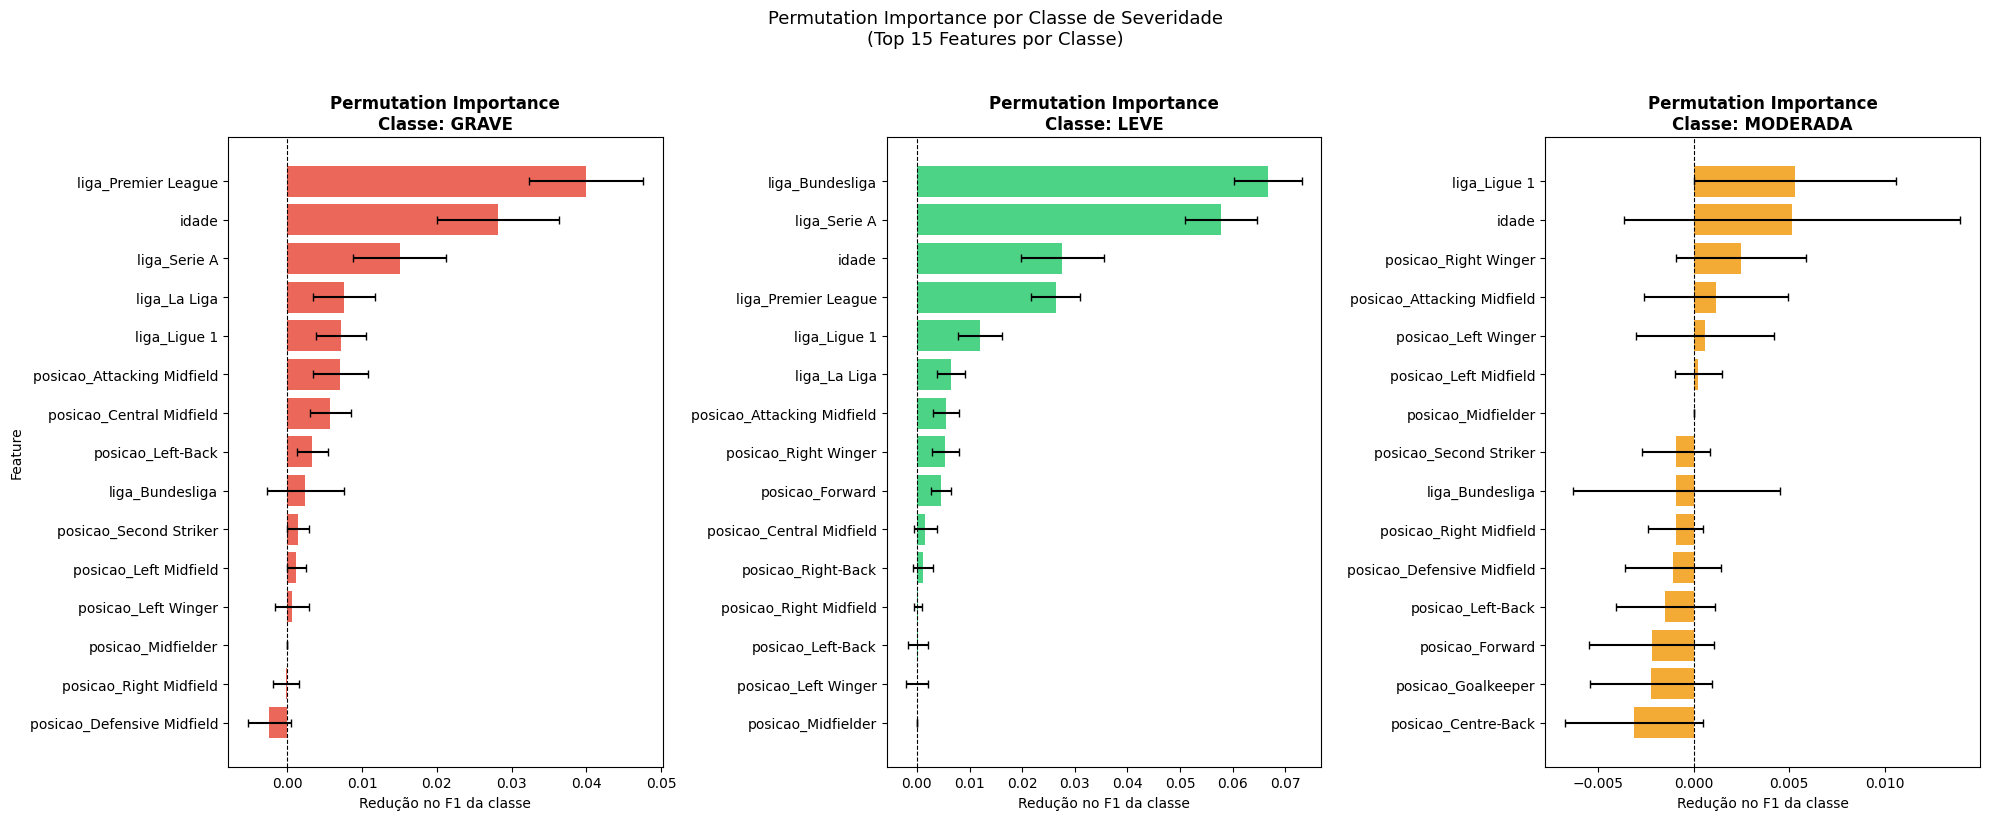

In [8]:
# ── Visualizar Top 15 por classe ─────────────────────────────────────────
cores = {'leve': '#2ecc71', 'moderada': '#f39c12', 'grave': '#e74c3c'}
fig, axes = plt.subplots(1, 3, figsize=(20, 8))

for ax, cls in zip(axes, classes):
    top15 = pi_per_class[cls].head(15)
    ax.barh(
        top15['feature'][::-1],
        top15['importance_mean'][::-1],
        xerr=top15['importance_std'][::-1],
        color=cores[cls], alpha=0.85, capsize=3
    )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Permutation Importance\nClasse: {cls.upper()}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Redução no F1 da classe')

axes[0].set_ylabel('Feature')
plt.suptitle('Permutation Importance por Classe de Severidade\n(Top 15 Features por Classe)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/img/permutation_por_classe.png', dpi=150, bbox_inches='tight')
plt.show()

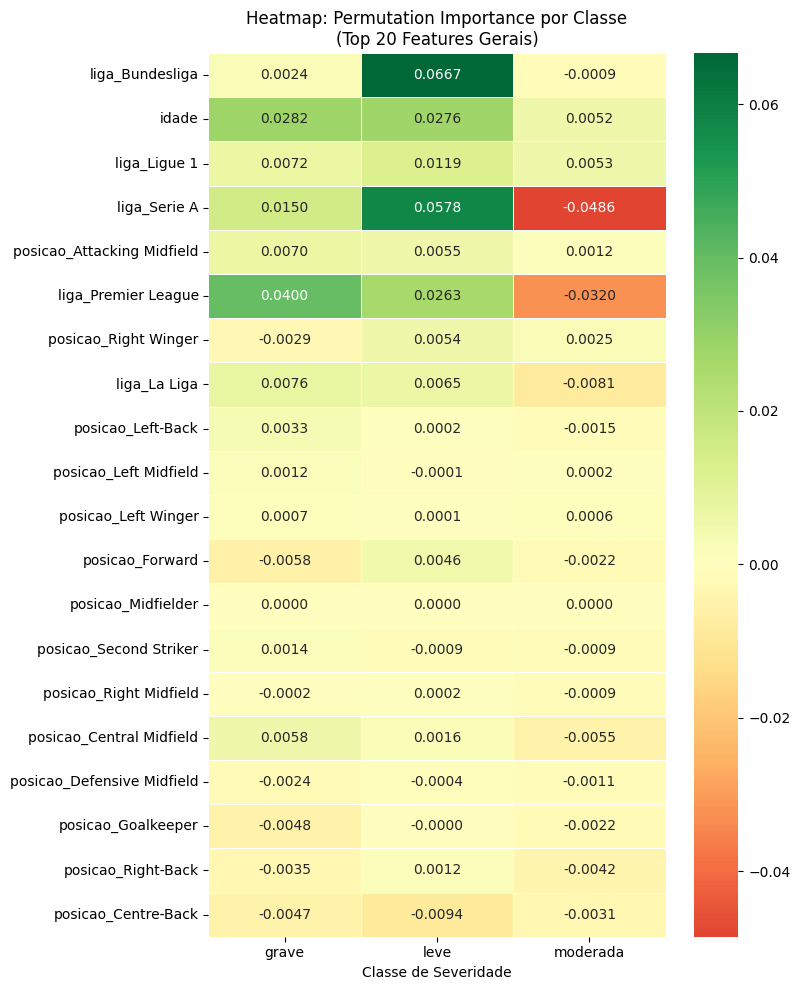

In [9]:
# ── Comparação consolidada: heatmap de importâncias ─────────────────────
# Pegar top 20 features globais e comparar entre classes
top_features = pi_df.head(20)['feature'].tolist()

heatmap_data = pd.DataFrame(
    {cls: pi_per_class[cls].set_index('feature')['importance_mean']
     for cls in classes},
    index=top_features
)

fig, ax = plt.subplots(figsize=(8, 10))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.4f', cmap='RdYlGn',
    linewidths=0.5, ax=ax, center=0
)
ax.set_title('Heatmap: Permutation Importance por Classe\n(Top 20 Features Gerais)', fontsize=12)
ax.set_xlabel('Classe de Severidade')
plt.tight_layout()
plt.savefig('../../docs/img/permutation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Análise SHAP (SHapley Additive exPlanations)

**O que é?** SHAP usa teoria dos jogos cooperativos para explicar cada previsão
individualmente. Para cada amostra e cada feature, calcula um valor SHAP que representa
**quanto aquela feature empurrou a previsão para cima ou para baixo**.

**Diferença em relação à Permutation Importance:**

| Aspecto | Permutation Importance | SHAP |
|---------|----------------------|------|
| Granularidade | Por feature (média global) | Por feature e por amostra |
| Interações | Não captura | Captura parcialmente |
| Velocidade | Mais rápido | Mais lento |
| Explicabilidade | Global | Global + Local |

Usamos `TreeExplainer`, otimizado para modelos baseados em árvores (Random Forest).

In [10]:
# ── Configurar SHAP ──────────────────────────────────────────────────────
# Amostra para visualização (SHAP pode ser lento em datasets grandes)
SAMPLE_SIZE = 500
X_sample = X_test.sample(SAMPLE_SIZE, random_state=42)

explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)
# shap_values é uma lista com 3 arrays (um por classe)
# shape de cada array: (SAMPLE_SIZE, n_features)

print(f'SHAP calculado para {SAMPLE_SIZE} amostras')
print(f'Classes: {rf.classes_}')
print(f'Shape dos valores SHAP por classe: {shap_values[0].shape}')

SHAP calculado para 500 amostras
Classes: ['grave' 'leve' 'moderada']
Shape dos valores SHAP por classe: (20, 3)


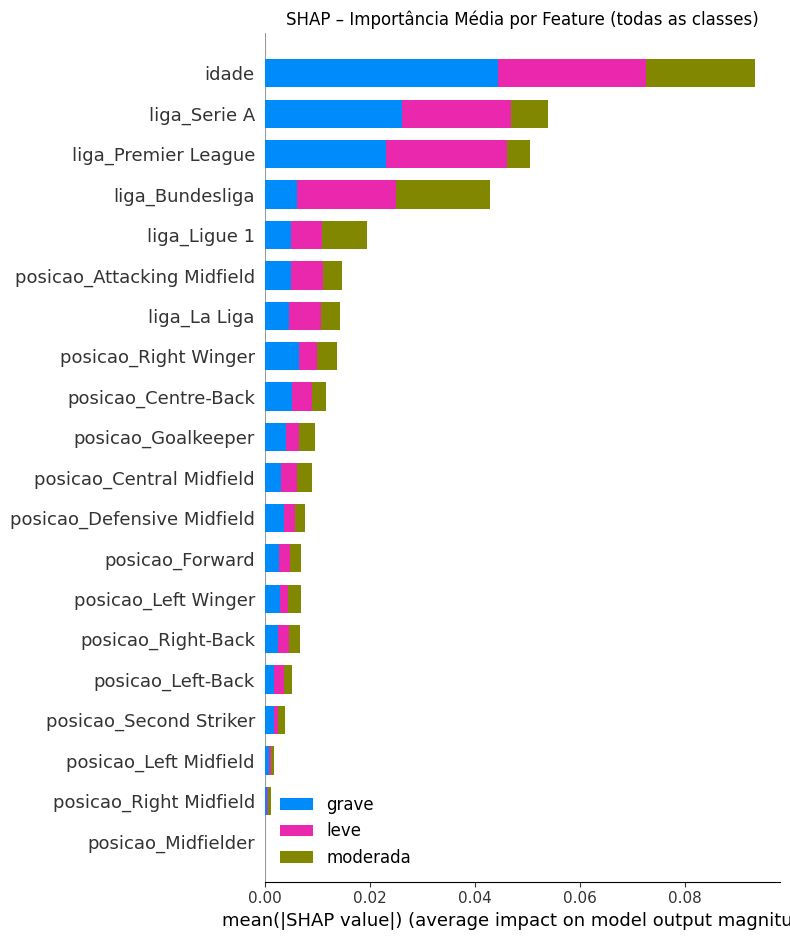

In [11]:
# ── Summary Plot Geral (impacto médio por feature) ───────────────────────
# SHAP 3D: shape (n_amostras, n_features, n_classes)
# Para summary_plot multiclasse passamos lista de slices por classe
shap_by_class = [shap_values[:, :, i] for i in range(shap_values.shape[2])]

shap.summary_plot(
    shap_by_class,
    X_sample,
    plot_type='bar',
    max_display=20,
    class_names=list(rf.classes_),
    show=False
)
plt.title('SHAP – Importância Média por Feature (todas as classes)', fontsize=12)
plt.tight_layout()
plt.savefig('../../docs/img/shap_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()

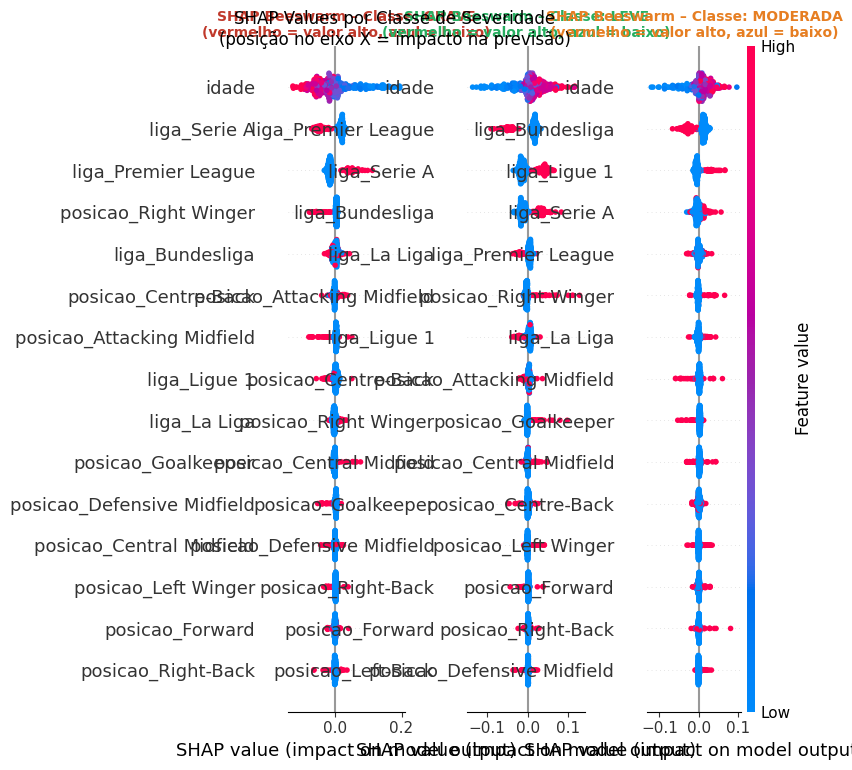

In [12]:
# ── Beeswarm por Classe ───────────────────────────────────────────────────
cores_shap = {'leve': '#27ae60', 'moderada': '#e67e22', 'grave': '#c0392b'}

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for i, cls in enumerate(rf.classes_):
    plt.sca(axes[i])
    shap.summary_plot(
        shap_values[:, :, i],
        X_sample,
        max_display=15,
        show=False,
        plot_type='dot',
        color_bar=(i == 2)  # Mostrar barra de cores apenas no último
    )
    axes[i].set_title(f'SHAP Beeswarm – Classe: {cls.upper()}\n(vermelho = valor alto, azul = baixo)',
                      fontsize=10, fontweight='bold', color=cores_shap[cls])

plt.suptitle('SHAP Values por Classe de Severidade\n(posição no eixo X = impacto na previsão)', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/img/shap_beeswarm_classes.png', dpi=150, bbox_inches='tight')
plt.show()

Exemplos de explicação individual por classe:



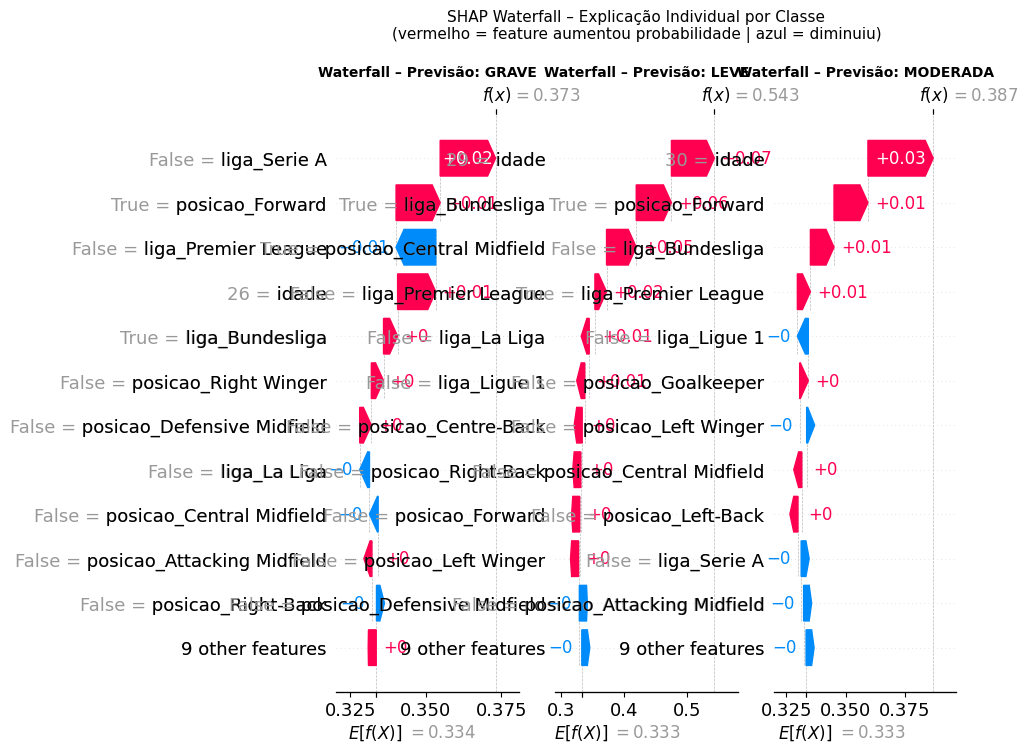

In [13]:
# ── SHAP Waterfall: explicando previsões individuais ─────────────────────
# Mostrar 1 exemplo de cada classe para tornar a análise concreta
print('Exemplos de explicação individual por classe:\n')

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

for i, cls in enumerate(rf.classes_):
    # Pegar o índice de uma amostra do conjunto de teste que foi classificada como `cls`
    y_pred_sample = rf.predict(X_sample)
    mask = (y_pred_sample == cls)
    if mask.sum() == 0:
        print(f'Nenhuma amostra prevista como {cls}')
        continue

    idx = np.where(mask)[0][0]  # Primeiro índice da classe
    ev = explainer.expected_value
    expected_val = ev[i] if hasattr(ev, "__len__") else ev
    sv = shap_values[idx, :, i]

    plt.sca(axes[i])
    shap.waterfall_plot(
        shap.Explanation(
            values=sv,
            base_values=expected_val,
            data=X_sample.iloc[idx],
            feature_names=list(X_sample.columns)
        ),
        max_display=12,
        show=False
    )
    axes[i].set_title(f'Waterfall – Previsão: {cls.upper()}', fontsize=10, fontweight='bold')

plt.suptitle('SHAP Waterfall – Explicação Individual por Classe\n'
             '(vermelho = feature aumentou probabilidade | azul = diminuiu)', fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig('../../docs/img/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
# ── Interaction Plot: SHAP Dependence (feature mais importante) ──────────
# Usa a feature mais importante globalmente
top_feature = pi_df.iloc[0]['feature']
print(f'Feature mais importante: {top_feature}\n')

# Se for numérica (idade), fazer dependence plot
if top_feature == 'idade':
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, cls in enumerate(rf.classes_):
        axes[i].scatter(
            X_sample['idade'],
            shap_values[:, X_sample.columns.get_loc('idade'), i],
            c=shap_values[:, X_sample.columns.get_loc('idade'), i],
            cmap='RdYlGn', alpha=0.6, s=15
        )
        axes[i].axhline(0, color='black', linewidth=0.8, linestyle='--')
        axes[i].set_xlabel('Idade do jogador')
        axes[i].set_ylabel(f'SHAP value (classe: {cls})')
        axes[i].set_title(f'Idade × SHAP – Classe: {cls.upper()}')
    plt.suptitle('Dependência SHAP: Idade do Jogador por Classe', fontsize=12)
    plt.tight_layout()
    plt.savefig('../../docs/img/shap_dependence_idade.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f'Feature {top_feature} é categórica – dependence plot não aplicável.')

Feature mais importante: liga_Bundesliga

Feature liga_Bundesliga é categórica – dependence plot não aplicável.


## 6. Conclusões

### Permutation Importance Geral

A análise de Permutation Importance global identificou as features que, ao serem
embaralhadas, causam maior degradação no F1-ponderado do modelo. Features com
importância positiva elevada são essenciais para a capacidade preditiva geral.
Features próximas de zero (ou negativas) podem ser removidas sem perda de desempenho.

### Permutation Importance por Classe

A análise por classe revelou que **diferentes features têm impacto distinto** dependendo
da severidade a ser prevista:
- **Leve:** Tende a ser influenciada por features de baixa intensidade de esforço (posição, liga).
- **Moderada:** Classe com maior distribuição; features gerais têm mais peso.
- **Grave:** Casos extremos — features que diferenciam lesões severas ganham relevância.

### SHAP

O SHAP complementa a Permutation Importance ao:
1. **Revelar a direção do efeito** (valor alto de uma feature aumenta ou diminui a previsão de 'grave'?).
2. **Explicar casos individuais** (Waterfall plot mostra exatamente por que o modelo previu 'grave' para um jogador específico).
3. **Identificar não-linearidades** (Dependence plot mostra se o efeito da idade é linear ou tem pontos de inflexão).

### Implicações para o Projeto

| Achado | Implicação |
|--------|------------|
| Features de posição e liga dominam a Permutation Importance | Variáveis táticas e contextuais são mais preditivas que apenas a idade |
| SHAP mostra efeitos heterogêneos por amostra | O modelo captura padrões complexos, não apenas regras simples |
| Classes raras (grave) têm features distintas | Estratégias de balanceamento e features específicas podem melhorar detecção de lesões graves |
